# Sprawdzenie optymalnej liczby kroków treningu

In [7]:
import re
import pandas as pd
import matplotlib.pyplot as plt

IMG_DIR = "../docs/tex/img"

# Wczytaj i przetwórz dane
df = pd.read_csv("validate_steps.csv")

def parse_model_metadata(model_name: str):
    name = str(model_name).replace(".zip", "")
    traffic_type = "fixed" if "fixed" in name else "random" if "random" in name else "unknown"
    match = re.search(r"_(\d+)([kKmM]?)_steps$", name) or re.search(r"_(\d+)([kKmM]?)$", name)
    if not match:
        return traffic_type, None
    steps = int(match.group(1))
    suffix = match.group(2).lower()
    if suffix == "k":
        steps *= 1_000
    elif suffix == "m":
        steps *= 1_000_000
    return traffic_type, steps

meta = df["model_name"].apply(parse_model_metadata)
df[["traffic_type", "steps"]] = pd.DataFrame(meta.tolist(), index=df.index)
df = df[df["traffic_type"].isin(["fixed", "random"]) & df["steps"].notna()].copy()
df["steps"] = df["steps"].astype(int)
df["route_label"] = df["route_file"].str.replace("routes_valid_", "", regex=False).str.replace(".rou", "", regex=False)

ROUTE_LABELS_PL = {
    "light": "lekki",
    "medium": "średni",
    "heavy": "ciężki",
    "random": "losowy",
}
df["route_label"] = df["route_label"].map(lambda x: ROUTE_LABELS_PL.get(x, x))


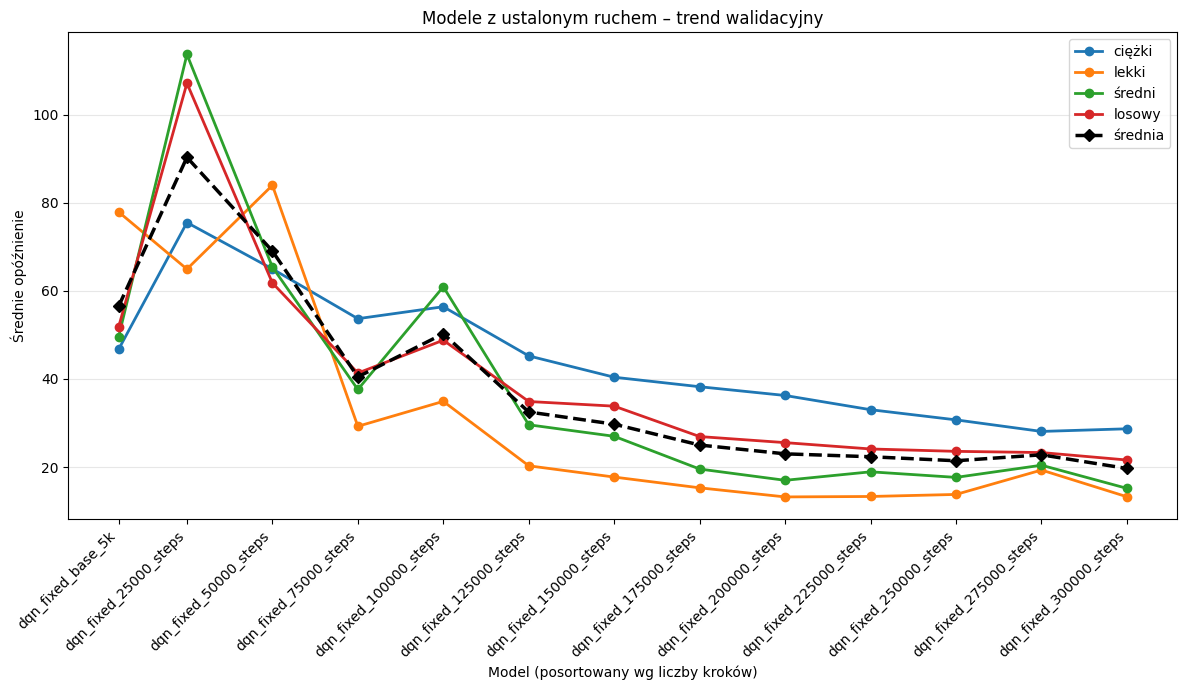

Modele ustalone:
            model_name  steps  mean_delay  poprawa_vs_poprzedni
     dqn_fixed_base_5k   5000   56.481554                   NaN
 dqn_fixed_25000_steps  25000   90.319823            -33.838269
 dqn_fixed_50000_steps  50000   69.047283             21.272540
 dqn_fixed_75000_steps  75000   40.474534             28.572749
dqn_fixed_100000_steps 100000   50.261175             -9.786641
dqn_fixed_125000_steps 125000   32.501740             17.759436
dqn_fixed_150000_steps 150000   29.732615              2.769125
dqn_fixed_175000_steps 175000   24.999814              4.732801
dqn_fixed_200000_steps 200000   23.002659              1.997155
dqn_fixed_225000_steps 225000   22.342501              0.660158
dqn_fixed_250000_steps 250000   21.430627              0.911874
dqn_fixed_275000_steps 275000   22.780759             -1.350132
dqn_fixed_300000_steps 300000   19.678708              3.102050


In [8]:
# Modele z ustalonym ruchem
fixed = df[df["traffic_type"] == "fixed"].copy()
if not fixed.empty:
    model_order_df = fixed[["model_name", "steps"]].drop_duplicates().sort_values("steps")
    step_to_model = dict(zip(model_order_df["steps"], model_order_df["model_name"]))

    plt.figure(figsize=(12, 7))
    for route_label, group in fixed.groupby("route_label", sort=False):
        g = group.groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
        plt.plot(g["steps"], g["mean_delay"], marker="o", linewidth=2, label=route_label)

    avg = fixed.groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
    plt.plot(avg["steps"], avg["mean_delay"], marker="D", linestyle="--", linewidth=2.5, color="black", label="średnia")

    ticks = sorted(step_to_model.keys())
    plt.xticks(ticks, [step_to_model[s] for s in ticks], rotation=45, ha="right")
    plt.xlabel("Model (posortowany wg liczby kroków)")
    plt.ylabel("Średnie opóźnienie")
    plt.title("Modele z ustalonym ruchem – trend walidacyjny")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{IMG_DIR}/validate_steps_fixed.png", dpi=150)
    plt.show()

    avg["poprawa_vs_poprzedni"] = avg["mean_delay"].shift(1) - avg["mean_delay"]
    avg["model_name"] = avg["steps"].map(step_to_model)
    print("Modele ustalone:")
    print(avg[["model_name", "steps", "mean_delay", "poprawa_vs_poprzedni"]].to_string(index=False))


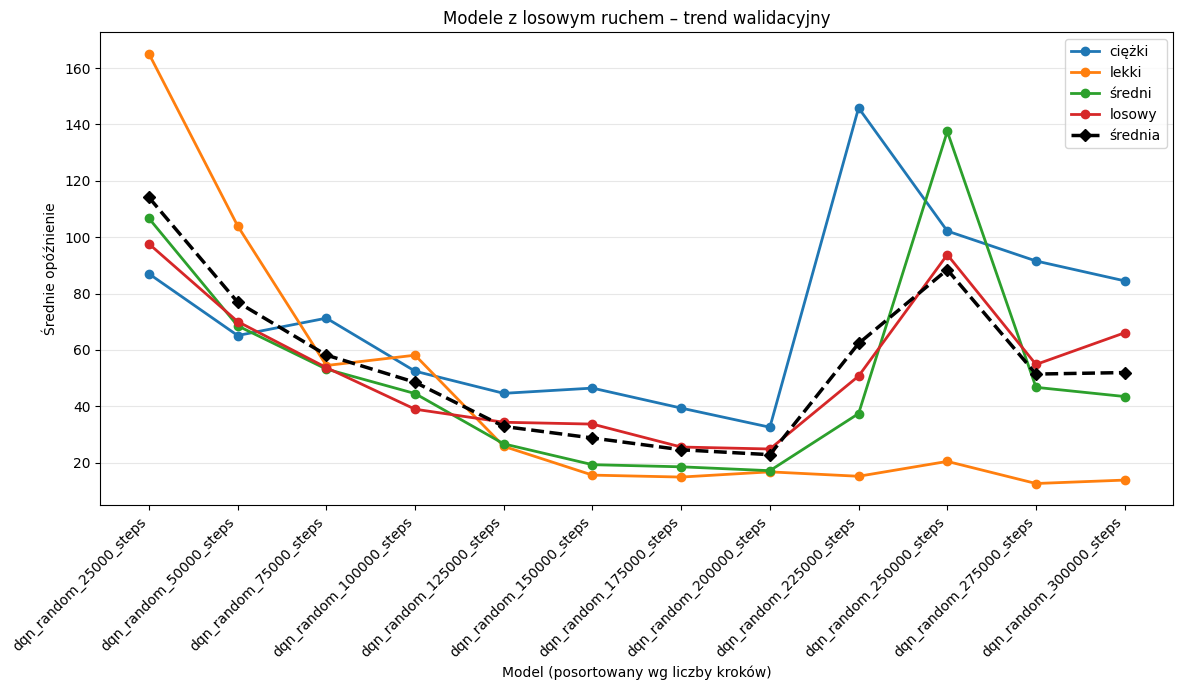

Modele losowe:
             model_name  steps  mean_delay  poprawa_vs_poprzedni
 dqn_random_25000_steps  25000  114.080100                   NaN
 dqn_random_50000_steps  50000   76.924350             37.155750
 dqn_random_75000_steps  75000   58.158161             18.766188
dqn_random_100000_steps 100000   48.508601              9.649561
dqn_random_125000_steps 125000   32.839157             15.669444
dqn_random_150000_steps 150000   28.742079              4.097078
dqn_random_175000_steps 175000   24.574591              4.167488
dqn_random_200000_steps 200000   22.821418              1.753174
dqn_random_225000_steps 225000   62.284808            -39.463390
dqn_random_250000_steps 250000   88.471759            -26.186952
dqn_random_275000_steps 275000   51.425842             37.045917
dqn_random_300000_steps 300000   51.959899             -0.534056


In [9]:
# Modele z losowym ruchem
random = df[df["traffic_type"] == "random"].copy()
if not random.empty:
    model_order_df = random[["model_name", "steps"]].drop_duplicates().sort_values("steps")
    step_to_model = dict(zip(model_order_df["steps"], model_order_df["model_name"]))

    plt.figure(figsize=(12, 7))
    for route_label, group in random.groupby("route_label", sort=False):
        g = group.groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
        plt.plot(g["steps"], g["mean_delay"], marker="o", linewidth=2, label=route_label)

    avg = random.groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
    plt.plot(avg["steps"], avg["mean_delay"], marker="D", linestyle="--", linewidth=2.5, color="black", label="średnia")

    ticks = sorted(step_to_model.keys())
    plt.xticks(ticks, [step_to_model[s] for s in ticks], rotation=45, ha="right")
    plt.xlabel("Model (posortowany wg liczby kroków)")
    plt.ylabel("Średnie opóźnienie")
    plt.title("Modele z losowym ruchem – trend walidacyjny")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{IMG_DIR}/validate_steps_random.png", dpi=150)
    plt.show()

    avg["poprawa_vs_poprzedni"] = avg["mean_delay"].shift(1) - avg["mean_delay"]
    avg["model_name"] = avg["steps"].map(step_to_model)
    print("Modele losowe:")
    print(avg[["model_name", "steps", "mean_delay", "poprawa_vs_poprzedni"]].to_string(index=False))
else:
    print("Brak danych dla modeli z losowym ruchem.")


# Strojenie hiperparametrów modelu z ustalonym ruchem

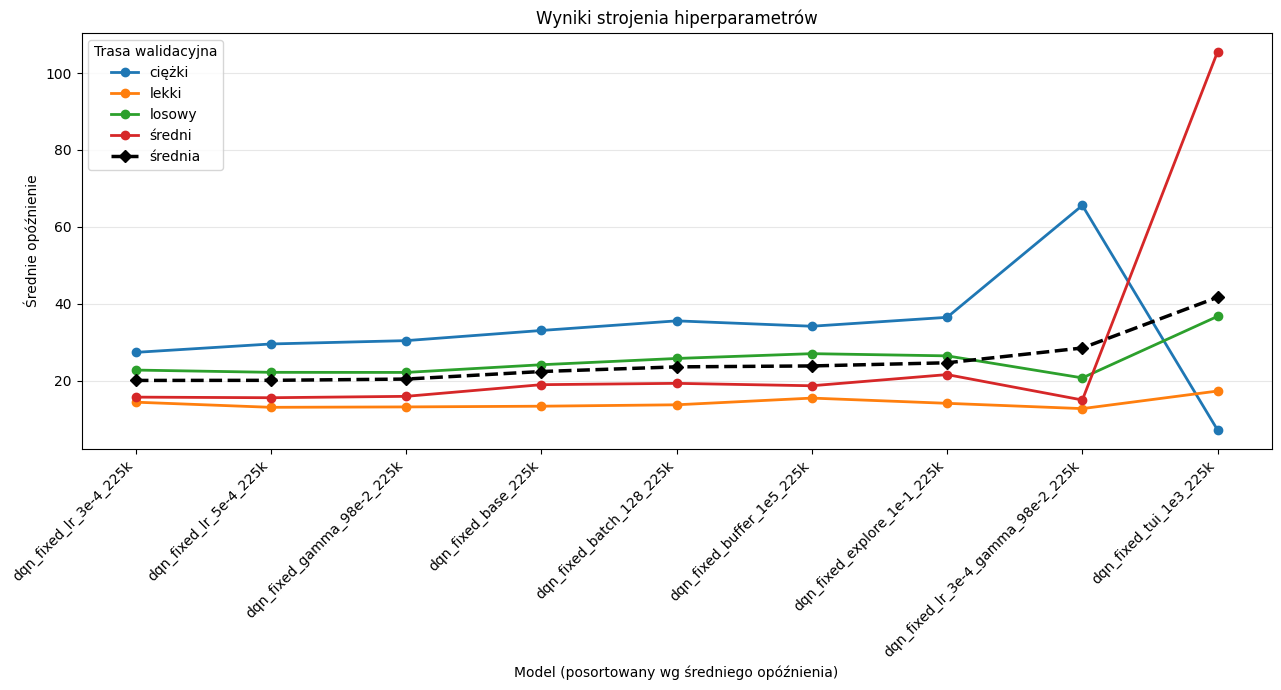

Ranking modeli wg średniego opóźnienia (niższe = lepsze):
model_name
dqn_fixed_lr_3e-4_225k                20.024190
dqn_fixed_lr_5e-4_225k                20.050231
dqn_fixed_gamma_98e-2_225k            20.377475
dqn_fixed_base_225k                   22.342501
dqn_fixed_batch_128_225k              23.554451
dqn_fixed_buffer_1e5_225k             23.797109
dqn_fixed_explore_1e-1_225k           24.619719
dqn_fixed_lr_3e-4_gamma_98e-2_225k    28.468287
dqn_fixed_tui_1e3_225k                41.657137


In [10]:
# Niezależne porównanie hiperparametrów
hp = pd.read_csv("validation_results.csv")
hp["route_label"] = hp["route_file"].str.replace("routes_valid_", "", regex=False).str.replace(".rou", "", regex=False)
hp["route_label"] = hp["route_label"].map(lambda x: ROUTE_LABELS_PL.get(x, x))

# Wiersze: model_name, kolumny: trasa, wartości: mean_delay
pivot = hp.pivot_table(index="model_name", columns="route_label", values="mean_delay", aggfunc="mean")
pivot["śr. opóźnienie"] = pivot.mean(axis=1)
pivot = pivot.sort_values("śr. opóźnienie")

plt.figure(figsize=(13, 7))
for route in [c for c in pivot.columns if c != "śr. opóźnienie"]:
    plt.plot(pivot.index, pivot[route], marker="o", linewidth=2, label=route)

plt.plot(
    pivot.index,
    pivot["śr. opóźnienie"],
    marker="D",
    linestyle="--",
    linewidth=2.5,
    color="black",
    label="średnia",
)

plt.xlabel("Model (posortowany wg średniego opóźnienia)")
plt.ylabel("Średnie opóźnienie")
plt.title("Wyniki strojenia hiperparametrów")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Trasa walidacyjna")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/hyperparameter_tuning.png", dpi=150)
plt.show()

print("Ranking modeli wg średniego opóźnienia (niższe = lepsze):")
print(pivot["śr. opóźnienie"].to_string())


# Wizualizacja wyników końcowych

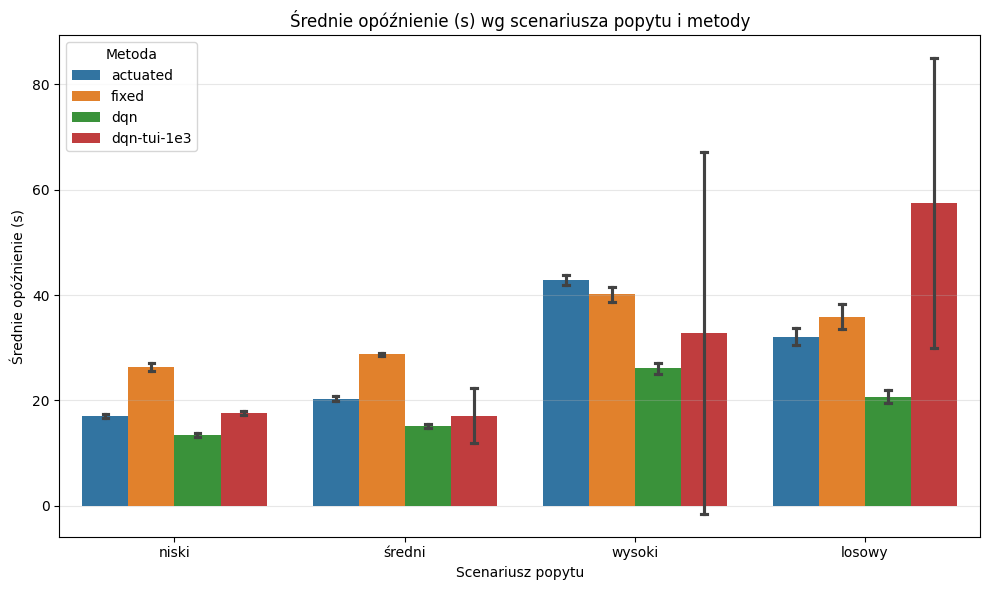

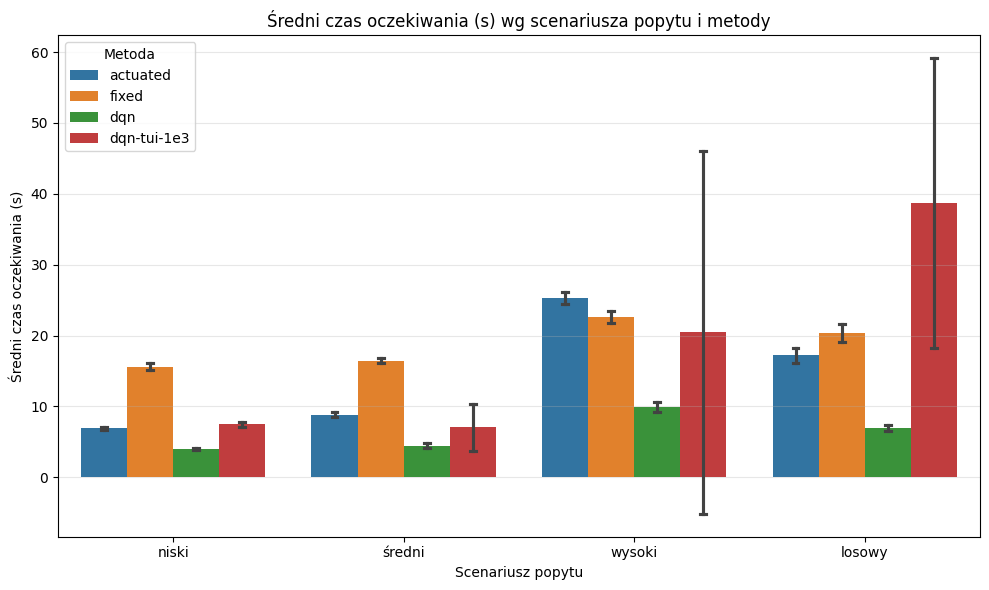

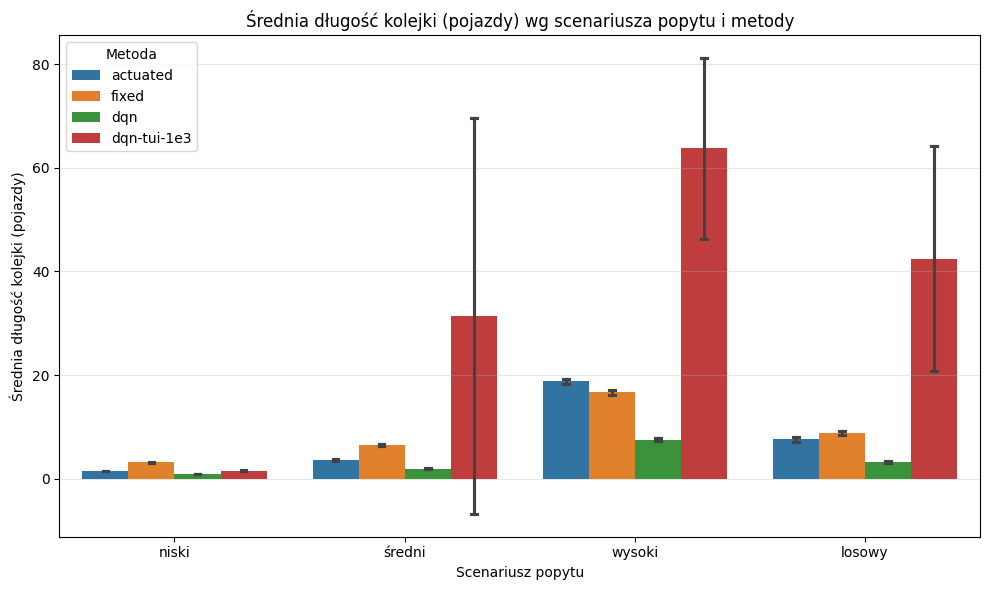

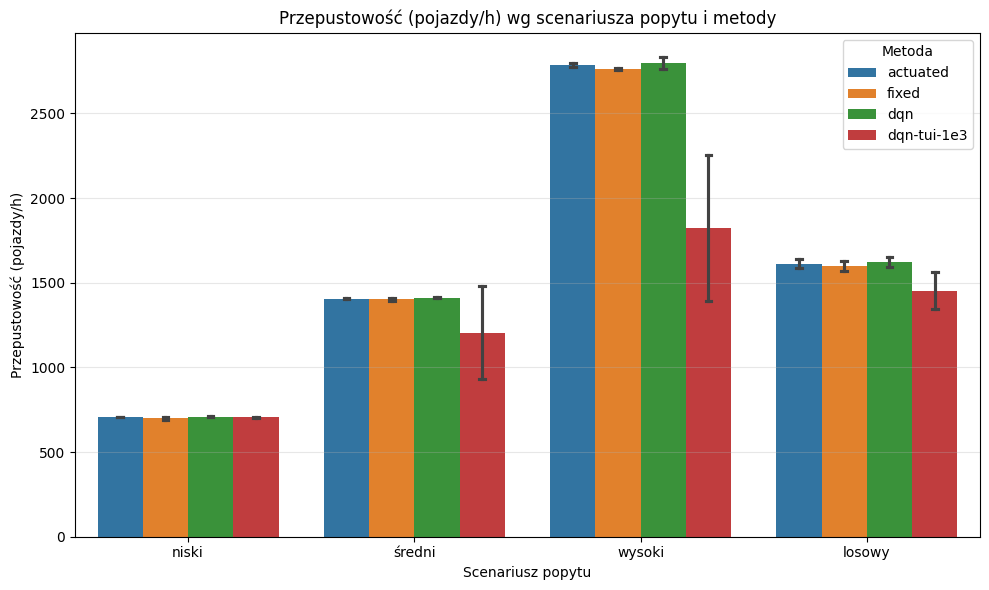

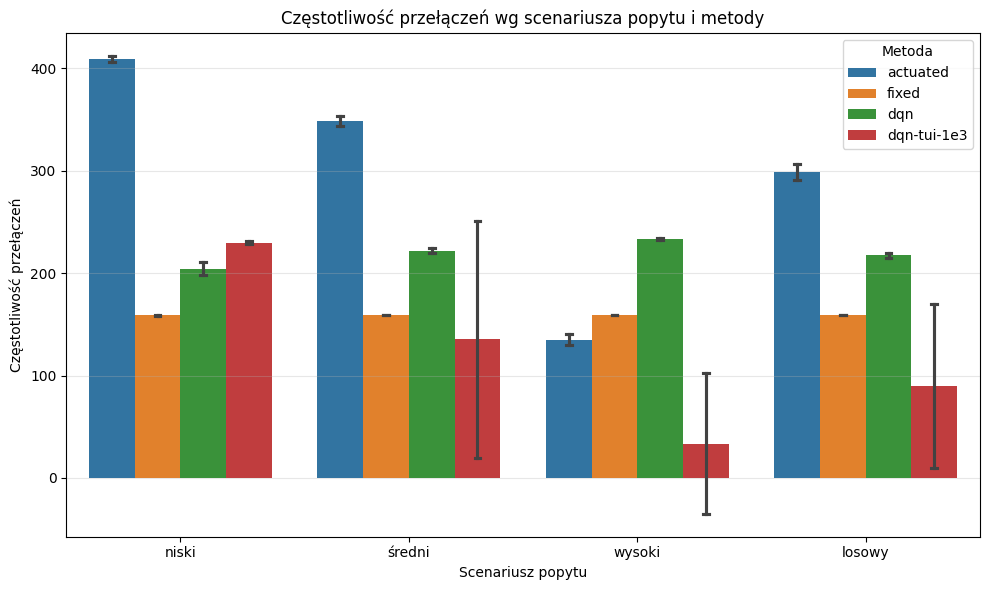

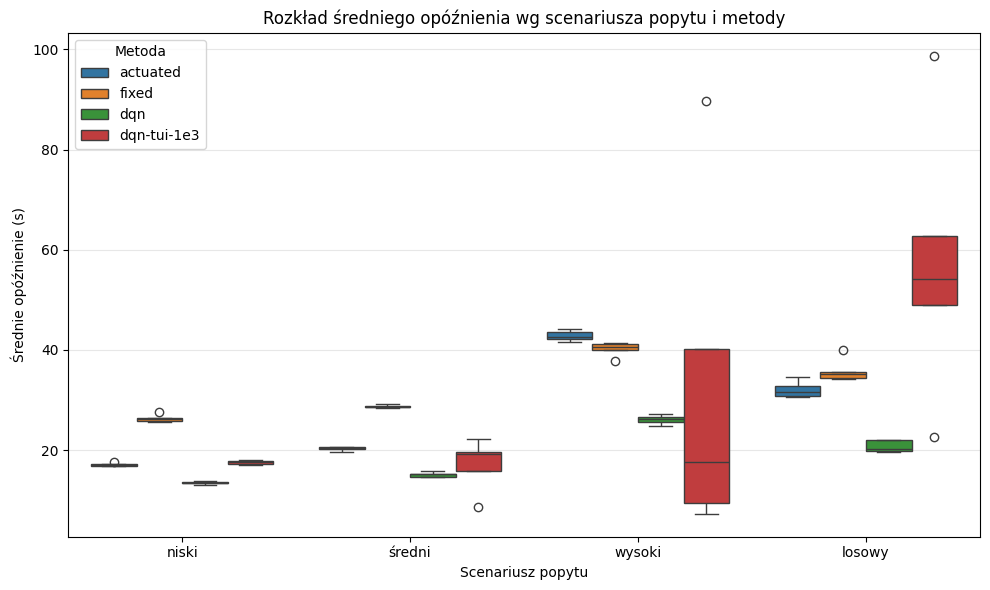

In [11]:
import seaborn as sns

res = pd.read_csv("results.csv")

DEMAND_PL = {"low": "niski", "medium": "średni", "high": "wysoki", "random": "losowy"}
res["demand"] = res["demand"].map(lambda x: DEMAND_PL.get(x, x))
demand_order = ["niski", "średni", "wysoki", "losowy"]

metrics = [
    ("mean_delay", "Średnie opóźnienie (s)", "mean_delay"),
    ("mean_waiting", "Średni czas oczekiwania (s)", "mean_waiting"),
    ("mean_queue", "Średnia długość kolejki (pojazdy)", "mean_queue"),
    ("throughput", "Przepustowość (pojazdy/h)", "throughput"),
    ("switching_freq", "Częstotliwość przełączeń", "switching_freq"),
]

for col, ylabel, fname in metrics:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=res, x="demand", y=col, hue="method", order=demand_order, errorbar="sd", capsize=0.1)
    plt.title(f"{ylabel} wg scenariusza popytu i metody")
    plt.ylabel(ylabel)
    plt.xlabel("Scenariusz popytu")
    plt.legend(title="Metoda")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{IMG_DIR}/results_bar_{fname}.png", dpi=150)
    plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=res, x="demand", y="mean_delay", hue="method", order=demand_order)
plt.title("Rozkład średniego opóźnienia wg scenariusza popytu i metody")
plt.ylabel("Średnie opóźnienie (s)")
plt.xlabel("Scenariusz popytu")
plt.legend(title="Metoda")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/results_boxplot_mean_delay.png", dpi=150)
plt.show()


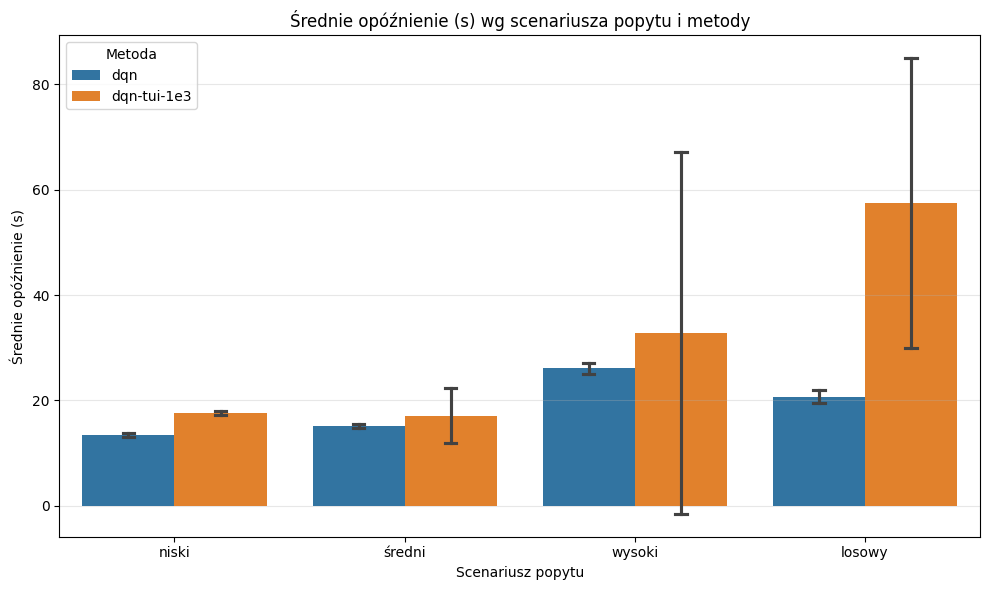

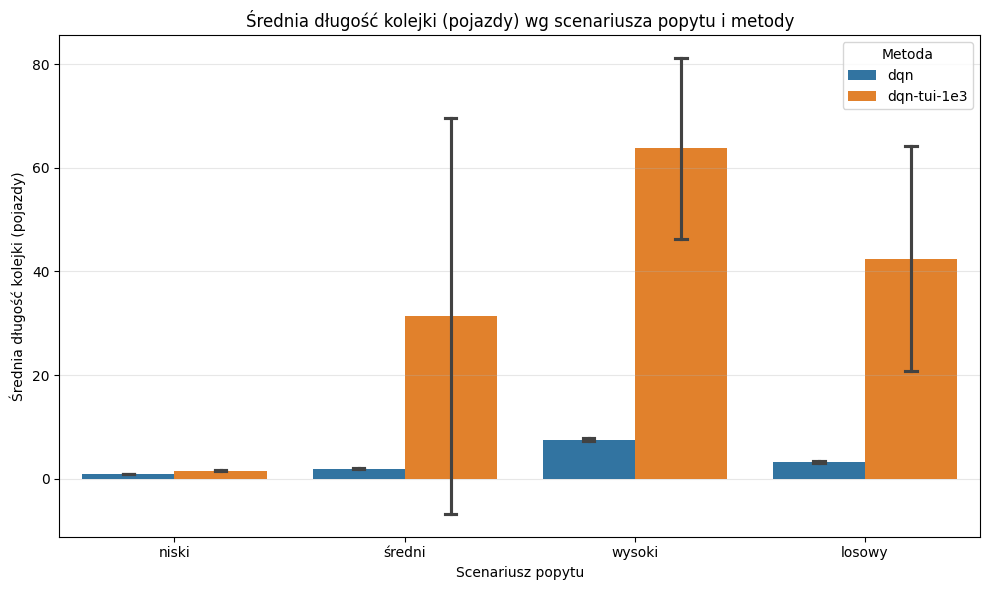

In [12]:
import seaborn as sns

res = pd.read_csv("results.csv")
methods_to_compare = ["dqn", "dqn-tui-1e3"]
res = res[res["method"].isin(methods_to_compare)].copy()

DEMAND_PL = {"low": "niski", "medium": "średni", "high": "wysoki", "random": "losowy"}
res["demand"] = res["demand"].map(lambda x: DEMAND_PL.get(x, x))
demand_order = ["niski", "średni", "wysoki", "losowy"]

metrics = [
    ("mean_delay", "Średnie opóźnienie (s)", "mean_delay_2"),
    ("mean_queue", "Średnia długość kolejki (pojazdy)", "mean_queue_2"),
]

for col, ylabel, fname in metrics:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=res, x="demand", y=col, hue="method", hue_order=methods_to_compare,
                order=demand_order, errorbar="sd", capsize=0.1)
    plt.title(f"{ylabel} wg scenariusza popytu i metody")
    plt.ylabel(ylabel)
    plt.xlabel("Scenariusz popytu")
    plt.legend(title="Metoda")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{IMG_DIR}/results_bar_{fname}.png", dpi=150)
    plt.show()